# Company A Churn Prediction PoC

Company A is an anonymous telecommunications provider with historical customer and usage data.

The objective of this notebook is to identify churn drivers, build a machine learning model to predict customer churn, and translate the findings into a business proposal focused on targeted retention actions.

2. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

3. Load Data

4. Data Understanding

In [2]:
client = pd.read_csv("telecom/Client.csv")
record = pd.read_csv("telecom/Record.csv")

print("Client shape:", client.shape)
print("Record shape:", record.shape)

client.head()

Client shape: (100000, 50)
Record shape: (100000, 51)


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [3]:
record.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005


In [4]:
client.info()
record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 50 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  object 
 3   crclscod          100000 non-null  object 
 4   asl_flag          100000 non-null  object 
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           100

In [5]:
client.info()
record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 50 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  object 
 3   crclscod          100000 non-null  object 
 4   asl_flag          100000 non-null  object 
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           100

In [6]:
print("Client duplicated Customer_ID:", client["Customer_ID"].duplicated().sum())
print("Record duplicated Customer_ID:", record["Customer_ID"].duplicated().sum())

Client duplicated Customer_ID: 0
Record duplicated Customer_ID: 0


5. Merge Datasets

In [7]:
df = record.merge(client, on="Customer_ID", how="left")

print("Merged shape:", df.shape)
df.head()

Merged shape: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,O,0.0,I,U,U,U,U,U,Y,434.0


In [8]:
missing_client_match = df["totrev"].isna().mean()
print("Percentage of records without client match:", missing_client_match)

Percentage of records without client match: 0.0


6. Target Variable Review

In [9]:
df["churn"].value_counts()

churn
0    50438
1    49562
Name: count, dtype: int64

In [23]:
df["churn"].value_counts(normalize=True)

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64

In [ ]:
df["churn"].value_counts(normalize=True).plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Proportion")
plt.show()

In [12]:
id_columns = ["Customer_ID"]

8. EDA — Key Questions

EDA 1 — Churn?
A higher churn rate indicates revenue leakage and justifies a retention-focused proposal.

EDA 2 — Lower revenue customer churn?
Potenial Variables:

rev_Mean
totmrc_Mean
avg3rev
avgrev

In [13]:
churn_rate = df["churn"].mean()
print("Churn rate:", churn_rate)

Churn rate: 0.49562


EDA 3 — Fall related to churn?
Variables:

change_mou
change_rev

In [ ]:
df.groupby("churn")["rev_Mean"].mean().plot(kind="bar")
plt.title("Average Monthly Revenue by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Mean Monthly Revenue")
plt.show()

EDA 4 — Service trouble are associated with churn?
Variables:

drop_blk_Mean
drop_vce_Mean
blck_vce_Mean

In [ ]:
df.groupby("churn")["drop_blk_Mean"].mean().plot(kind="bar")
plt.title("Dropped or Blocked Calls by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Mean Dropped/Blocked Calls")
plt.show()

EDA 5 — Customer care indicates friction?
Variables:

custcare_Mean
cc_mou_Mean

In [ ]:
df.groupby("churn")["custcare_Mean"].mean().plot(kind="bar")
plt.title("Customer Care Calls by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Mean Customer Care Calls")
plt.show()

9. Business Problem Definition
EDA suggests that churn may be associated with changes in usage, revenue behavior, service quality indicators, and customer profile characteristics.

Business objective:
Reduce customer churn by identifying customers at high risk of leaving.

ML task:
Binary classification.

Target variable:
churn.

Business action:
Rank customers by predicted churn probability and prioritize retention campaigns for those with high churn risk and high customer value.

10. Feature Selection

In [20]:
target = "churn"

X = df.drop(columns=["churn", "Customer_ID"])
y = df[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

X shape: (100000, 98)
y shape: (100000,)
Numeric features: 77
Categorical features: 21


11. Preprocessing Pipeline

In [22]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

12. Train/Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (80000, 98)
X_test shape: (20000, 98)
y_train distribution:
churn
0    0.504375
1    0.495625
Name: proportion, dtype: float64
y_test distribution:
churn
0    0.5044
1    0.4956
Name: proportion, dtype: float64


13. Baseline Model — Logistic Regression

In [36]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_model.fit(X_train, y_train);

In [26]:
y_pred_lr = log_reg_model.predict(X_test)
y_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]

print("Model: Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

Model: Logistic Regression
Accuracy: 0.5956
Precision: 0.5886986967516048
Recall: 0.6106739305891848
F1-score: 0.5994849955432306
ROC-AUC: 0.6310252865981941


14. Main Model — Random Forest Classifier

In [35]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train);

In [29]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest Classifier"],
    "Accuracy": [accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_rf)],
    "F1-score": [f1_score(y_test, y_pred_rf)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_rf)]
})

rf_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest Classifier,0.6224,0.616555,0.629742,0.623078,0.670892


In [28]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Model: Random Forest Classifier")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Model: Random Forest Classifier
Accuracy: 0.6224
Precision: 0.6165547214539707
Recall: 0.6297417271993543
F1-score: 0.6230784587742064
ROC-AUC: 0.6708915138388316


In [33]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.5956,0.5887,0.6107,0.5995,0.6310
1,Random Forest Classifier,0.6224,0.6166,0.6297,0.6231,0.6709


In [37]:
print(model_comparison.round(4).to_string(index=False))

                   Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
     Logistic Regression    0.5956     0.5887  0.6107    0.5995   0.6310
Random Forest Classifier    0.6224     0.6166  0.6297    0.6231   0.6709


15. Model Comparison

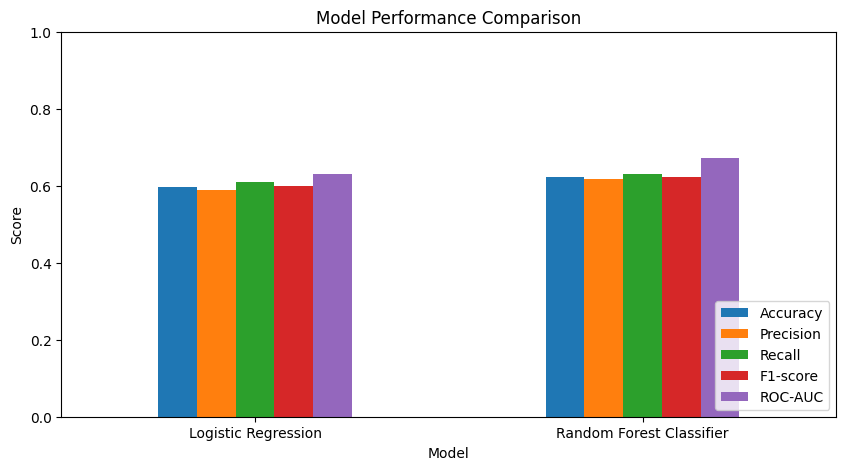

In [38]:
model_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

Random Forest Classifier outperformed Logistic Regression across all evaluation metrics. Therefore, Random Forest is selected as the main model for the churn-risk scoring proposal.

The primary metric is ROC-AUC because the business objective is to rank customers by churn risk and prioritize retention actions.

16. Business Scoring Table

In [39]:
scoring_df = X_test.copy()

scoring_df["Customer_ID"] = df.loc[X_test.index, "Customer_ID"]
scoring_df["actual_churn"] = y_test
scoring_df["predicted_churn_probability"] = y_proba_rf
scoring_df["monthly_revenue"] = df.loc[X_test.index, "rev_Mean"]

scoring_df["revenue_at_risk"] = (
    scoring_df["predicted_churn_probability"] *
    scoring_df["monthly_revenue"]
)

scoring_df = scoring_df.sort_values(
    "revenue_at_risk",
    ascending=False
)

scoring_df[[
    "Customer_ID",
    "actual_churn",
    "predicted_churn_probability",
    "monthly_revenue",
    "revenue_at_risk"
]].head(20)

,Customer_ID,actual_churn,predicted_churn_probability,monthly_revenue,revenue_at_risk
76358,1076359,1,0.445,861.1050,383.191725
45847,1045848,1,0.565,632.8750,357.574375
51687,1051688,0,0.555,563.7850,312.900675
96450,1096451,0,0.655,457.2100,299.472550
96490,1096491,0,0.630,471.6700,297.152100
62476,1062477,0,0.485,587.0350,284.711975
50725,1050726,1,0.640,443.7125,283.976000
49039,1049040,1,0.490,575.7500,282.117500
42738,1042739,0,0.500,558.9325,279.466250
44942,1044943,0,0.595,465.6400,277.055800


17. Quantified Business Impact

In [40]:
top_20_pct = scoring_df.head(int(len(scoring_df) * 0.20))

monthly_revenue_at_risk = top_20_pct["revenue_at_risk"].sum()

expected_retention_improvement = 0.10

protected_monthly_revenue = (
    monthly_revenue_at_risk * expected_retention_improvement
)

protected_annual_revenue = protected_monthly_revenue * 12

print("Number of customers in top 20% risk-value segment:", len(top_20_pct))
print("Monthly revenue at risk:", round(monthly_revenue_at_risk, 2))
print("Assumed retention improvement:", expected_retention_improvement)
print("Protected monthly revenue:", round(protected_monthly_revenue, 2))
print("Protected annual revenue:", round(protected_annual_revenue, 2))

Number of customers in top 20% risk-value segment: 4000
Monthly revenue at risk: 248619.09
Assumed retention improvement: 0.1
Protected monthly revenue: 24861.91
Protected annual revenue: 298342.91


The impact estimate assumes that Company A targets the top 20% of customers ranked by revenue at risk and successfully protects 10% of that monthly revenue through targeted retention actions.

This is a conservative PoC-level estimate. In a real implementation, the estimate should be refined by including campaign cost, retention offer cost, customer lifetime value, and operational capacity.

18. Business Interpretation

The Random Forest Classifier achieved the strongest performance among the tested models, with a ROC-AUC of 0.6709. This indicates that the model has a moderate ability to rank customers by churn risk.

Using the model's predicted churn probabilities, customers were ranked by revenue at risk. This allows Company A to prioritize retention actions toward customers who combine high churn risk with higher monthly revenue.

Under a conservative assumption that targeted retention actions protect 10% of the monthly revenue at risk among the top 20% prioritized customers, the estimated protected annual revenue is approximately $298,342.91.

This estimate should be considered a PoC-level business case and refined in future work by including retention campaign costs, offer costs, customer lifetime value, and operational capacity.

19. Feature Importance

In [ ]:
# Get fitted Random Forest model from pipeline
rf_classifier = rf_model.named_steps["classifier"]

# Get transformed feature names from preprocessing step
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Build feature importance table
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_classifier.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(20)

In [ ]:
top_features = feature_importance.head(15).copy()

top_features.sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
    figsize=(10, 6)
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The Random Forest model indicates that the strongest churn predictors are related to equipment age, changes in usage, customer tenure, revenue behavior, and historical usage intensity.

The most important feature is `eqpdays`, which represents the age of the current equipment. This suggests that customers with older devices may require proactive retention or upgrade offers.

Usage-change variables such as `change_mou` and revenue-related variables such as `change_rev`, `rev_Mean`, `totrev`, and `avgrev` indicate that churn risk is linked to both behavioral changes and customer value.

From a business perspective, these insights support a targeted retention strategy where Company A prioritizes customers with high churn probability, high revenue at risk, and signals such as declining usage or aging equipment.

In [43]:
feature_importance.head(20)

,feature,importance
76,num__eqpdays,0.031040
9,num__change_mou,0.023956
48,num__months,0.022895
54,num__adjrev,0.019519
1,num__mou_Mean,0.019289
53,num__totrev,0.019203
10,num__change_rev,0.019002
57,num__avgrev,0.018871
59,num__avgqty,0.018582
58,num__avgmou,0.018232


20. Conclusions and Next Steps

## Conclusions

This notebook developed a churn prediction PoC for Company A, an anonymous telecommunications provider.

The analysis combined customer profile data and service usage data using `Customer_ID` as the common key. The final modeling dataset contained customer usage behavior, revenue variables, service interaction indicators, customer profile attributes, and the target variable `churn`.

Two classification models were tested:

- Logistic Regression
- Random Forest Classifier

Random Forest Classifier achieved the strongest performance:

- Accuracy: 0.6224
- Precision: 0.6166
- Recall: 0.6297
- F1-score: 0.6231
- ROC-AUC: 0.6709

The primary evaluation metric is ROC-AUC because the business objective is to rank customers by churn risk and prioritize retention actions, rather than only predicting a binary label.

Using the Random Forest model, customers were ranked by predicted churn probability and revenue at risk. The top 20% risk-value segment included 4,000 customers.

Under a conservative assumption that targeted retention actions protect 10% of the monthly revenue at risk, the estimated protected annual revenue is approximately $298,342.91.

Feature importance suggests that churn risk is mainly associated with equipment age, changes in usage, customer tenure, revenue behavior, and historical usage intensity. These insights support a targeted retention strategy focused on proactive equipment upgrade offers, reactivation campaigns, plan optimization, and premium retention actions for high-value customers.

## Next Steps

1. Validate the model results with Company A business stakeholders.
2. Review campaign cost, retention offer cost, customer lifetime value, and gross margin to estimate net financial impact.
3. Pilot the churn-risk scoring approach with the top 20% risk-value customer segment.
4. Monitor retention campaign results against a control group.
5. Improve the model through hyperparameter tuning, additional feature engineering, and periodic retraining.
6. Deploy the scoring process into a business dashboard or CRM workflow for retention teams.